In [1]:
!pip install shap

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

import shap

from catboost import CatBoostRegressor

In [3]:
from pathlib import Path

CWD = Path.cwd()
PROJECT_ROOT = CWD.parent.parent
PROCESSED_DIR = PROJECT_ROOT / "Data" / "Processed"

print(PROCESSED_DIR)

C:\Users\Sameen\10 Pearls Project\AQI Predictor\Data\Processed


In [4]:
df = pd.read_csv(PROCESSED_DIR / "Aqi_Data_One_Day_Prediction_New.csv", index_col="time", parse_dates=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 26232 entries, 2023-08-04 00:00:00+05:00 to 2026-07-31 23:00:00+05:00
Data columns (total 50 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   temperature_2m             26232 non-null  float64
 1   wind_speed_10m             26232 non-null  float64
 2   relative_humidity_2m       26232 non-null  int64  
 3   surface_pressure           26232 non-null  float64
 4   boundary_layer_height      21864 non-null  float64
 5   dew_point_2m               26232 non-null  float64
 6   precipitation              26232 non-null  float64
 7   cloud_cover                26232 non-null  int64  
 8   wind_direction_10m         26232 non-null  int64  
 9   wind_gusts_10m             26232 non-null  float64
 10  shortwave_radiation        26232 non-null  float64
 11  pm10                       26232 non-null  float64
 12  pm2_5                      26232 non-null  float64
 13 

In [5]:
df.head()

,temperature_2m,wind_speed_10m,relative_humidity_2m,surface_pressure,boundary_layer_height,dew_point_2m,precipitation,cloud_cover,wind_direction_10m,wind_gusts_10m,...,f24_surface_pressure,f24_boundary_layer_height,f24_dew_point_2m,f24_precipitation,f24_cloud_cover,f24_wind_gusts_10m,f24_shortwave_radiation,wind_pollution_dispersion,pressure_change_3hour,Humidity_Level
time,,,,,,,,,,,,,,,,,,,,,
2023-08-04 00:00:00+05:00,27.4,18.7,90,1000.1,785.0,25.5,0.0,24,251,26.6,...,1002.2,625.0,25.2,0.0,48.0,19.8,0.0,14679.5,0.2,1.9
2023-08-04 01:00:00+05:00,27.2,19.0,90,999.3,810.0,25.5,0.0,23,255,27.0,...,1002.1,645.0,25.2,0.0,49.0,20.5,0.0,15390.0,-0.9,1.7
2023-08-04 02:00:00+05:00,27.0,17.7,92,998.6,790.0,25.5,0.0,19,257,27.4,...,1001.6,705.0,25.3,0.0,15.0,23.0,0.0,13983.0,-1.7,1.5
2023-08-04 03:00:00+05:00,26.9,17.1,92,998.7,845.0,25.5,0.0,49,255,25.2,...,1001.2,745.0,25.3,0.0,17.0,27.4,0.0,14449.5,-1.4,1.4
2023-08-04 04:00:00+05:00,27.0,20.0,92,998.8,830.0,25.5,0.0,33,262,28.4,...,1001.4,765.0,25.4,0.0,100.0,28.1,0.0,16600.0,-0.5,1.5


# Train And Test Split

In [6]:
df.columns

Index(['temperature_2m', 'wind_speed_10m', 'relative_humidity_2m',
       'surface_pressure', 'boundary_layer_height', 'dew_point_2m',
       'precipitation', 'cloud_cover', 'wind_direction_10m', 'wind_gusts_10m',
       'shortwave_radiation', 'pm10', 'pm2_5', 'carbon_monoxide',
       'nitrogen_dioxide', 'sulphur_dioxide', 'ozone', 'dust',
       'aerosol_optical_depth', 'us_aqi', 'hour', 'day', 'month', 'dayofweek',
       'quarter', 'previous_hour_aqi', 'previous_day_aqi', 'aqi_change_rate',
       'rolled_mean_aqi_6hr', 'rolled_mean_aqi_24hr', 'rolled_mean_aqi_72hr',
       'rolled_std_aqi_6hr', 'rolled_std_aqi_24hr', 'rolled_std_aqi_72hr',
       'ewm_aqi_24hr', 'ewm_std_24hr', 'Day_1_Future_AQI',
       'f24_temperature_2m', 'f24_wind_speed_10m', 'f24_relative_humidity_2m',
       'f24_surface_pressure', 'f24_boundary_layer_height', 'f24_dew_point_2m',
       'f24_precipitation', 'f24_cloud_cover', 'f24_wind_gusts_10m',
       'f24_shortwave_radiation', 'wind_pollution_dispersion

In [7]:
X = df.drop(columns = ['Day_1_Future_AQI'])
Y = df['Day_1_Future_AQI']

In [8]:
X

,temperature_2m,wind_speed_10m,relative_humidity_2m,surface_pressure,boundary_layer_height,dew_point_2m,precipitation,cloud_cover,wind_direction_10m,wind_gusts_10m,...,f24_surface_pressure,f24_boundary_layer_height,f24_dew_point_2m,f24_precipitation,f24_cloud_cover,f24_wind_gusts_10m,f24_shortwave_radiation,wind_pollution_dispersion,pressure_change_3hour,Humidity_Level
time,,,,,,,,,,,,,,,,,,,,,
2023-08-04 00:00:00+05:00,27.4,18.7,90,1000.1,785.0,25.5,0.0,24,251,26.6,...,1002.2,625.0,25.2,0.0,48.0,19.8,0.0,14679.5,0.2,1.9
2023-08-04 01:00:00+05:00,27.2,19.0,90,999.3,810.0,25.5,0.0,23,255,27.0,...,1002.1,645.0,25.2,0.0,49.0,20.5,0.0,15390.0,-0.9,1.7
2023-08-04 02:00:00+05:00,27.0,17.7,92,998.6,790.0,25.5,0.0,19,257,27.4,...,1001.6,705.0,25.3,0.0,15.0,23.0,0.0,13983.0,-1.7,1.5
2023-08-04 03:00:00+05:00,26.9,17.1,92,998.7,845.0,25.5,0.0,49,255,25.2,...,1001.2,745.0,25.3,0.0,17.0,27.4,0.0,14449.5,-1.4,1.4
2023-08-04 04:00:00+05:00,27.0,20.0,92,998.8,830.0,25.5,0.0,33,262,28.4,...,1001.4,765.0,25.4,0.0,100.0,28.1,0.0,16600.0,-0.5,1.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-07-31 19:00:00+05:00,30.2,9.7,82,994.7,330.0,26.7,0.0,90,214,28.8,...,997.3,545.0,25.3,0.0,98.0,35.6,42.0,3201.0,1.0,3.5
2026-07-31 20:00:00+05:00,29.7,9.2,86,995.5,360.0,27.1,0.0,80,230,26.3,...,997.9,530.0,25.2,0.0,99.0,30.2,1.0,3312.0,1.8,2.6
2026-07-31 21:00:00+05:00,29.6,7.5,87,996.2,355.0,27.2,0.0,75,240,23.0,...,998.4,490.0,25.2,0.0,100.0,29.9,0.0,2662.5,2.5,2.4


In [9]:
Y

time
2023-08-04 00:00:00+05:00    83.0
2023-08-04 01:00:00+05:00    83.0
2023-08-04 02:00:00+05:00    83.0
2023-08-04 03:00:00+05:00    83.0
2023-08-04 04:00:00+05:00    82.0
                             ... 
2026-07-31 19:00:00+05:00    89.0
2026-07-31 20:00:00+05:00    88.0
2026-07-31 21:00:00+05:00    88.0
2026-07-31 22:00:00+05:00    88.0
2026-07-31 23:00:00+05:00    88.0
Name: Day_1_Future_AQI, Length: 26232, dtype: float64

In [10]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, shuffle = False)

In [11]:
len(X_train)

20985

In [12]:
len(X_test)

5247

# Building CatBoost Model For Day One

In [13]:
cbr = CatBoostRegressor(iterations = 100,
                        depth = 6,
                        random_seed = 42,
                        learning_rate = 0.02,
                        l2_leaf_reg = 6,
                        loss_function = 'RMSE')

In [14]:
cbr.fit(X_train, Y_train)

0:	learn: 23.9437437	total: 145ms	remaining: 14.3s
1:	learn: 23.6618644	total: 174ms	remaining: 8.54s
2:	learn: 23.3606931	total: 206ms	remaining: 6.67s
3:	learn: 23.0858840	total: 256ms	remaining: 6.13s
4:	learn: 22.8034126	total: 305ms	remaining: 5.8s
5:	learn: 22.5314468	total: 355ms	remaining: 5.56s
6:	learn: 22.2612033	total: 402ms	remaining: 5.34s
7:	learn: 22.0126177	total: 434ms	remaining: 5s
8:	learn: 21.7620277	total: 477ms	remaining: 4.82s
9:	learn: 21.5222571	total: 528ms	remaining: 4.75s
10:	learn: 21.2851362	total: 568ms	remaining: 4.59s
11:	learn: 21.0506169	total: 605ms	remaining: 4.43s
12:	learn: 20.8155911	total: 640ms	remaining: 4.29s
13:	learn: 20.6025074	total: 668ms	remaining: 4.1s
14:	learn: 20.3894469	total: 713ms	remaining: 4.04s
15:	learn: 20.1784799	total: 764ms	remaining: 4.01s
16:	learn: 19.9767714	total: 817ms	remaining: 3.99s
17:	learn: 19.7760451	total: 860ms	remaining: 3.92s
18:	learn: 19.5836034	total: 898ms	remaining: 3.83s
19:	learn: 19.3988088	total

CatBoostRegressor(depth=6, iterations=100, l2_leaf_reg=6, learning_rate=0.02, loss_function='RMSE', random_seed=42)

In [15]:
y_pred = cbr.predict(X_test)

# Evaluating the Model

In [16]:
R2_Score = r2_score(Y_test, y_pred)
Mae = mean_absolute_error(Y_test, y_pred)
Mean_Square_Error = mean_squared_error(Y_test, y_pred)
Root_Mean_Square_Error = np.sqrt(Mean_Square_Error)

print("Evaluation Metrics: ")
print(f"R2 Score: {R2_Score}")
print(f"Mean Absolute Error: {Mae}")
print(f"Mean Square Error: {Mean_Square_Error}")
print(f"Root Mean Square Error: {Root_Mean_Square_Error}")

Evaluation Metrics: 
R2 Score: 0.5874796808774088
Mean Absolute Error: 9.087422929875165
Mean Square Error: 165.93253076587303
Root Mean Square Error: 12.881480146546554


# Note:
- Not much Improvement will come even if I do hyper parameter optimization. I will try other method

# Now Day Wise

In [17]:
day1 = pd.read_csv(PROCESSED_DIR / "Day_One_AQI.csv", index_col="time", parse_dates=True)
day1.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1092 entries, 2023-08-04 00:00:00+05:00 to 2026-07-30 00:00:00+05:00
Data columns (total 49 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   temperature_2m             1092 non-null   float64
 1   wind_speed_10m             1092 non-null   float64
 2   relative_humidity_2m       1092 non-null   float64
 3   surface_pressure           1092 non-null   float64
 4   boundary_layer_height      911 non-null    float64
 5   dew_point_2m               1092 non-null   float64
 6   precipitation              1092 non-null   float64
 7   cloud_cover                1092 non-null   float64
 8   wind_direction_10m         1092 non-null   float64
 9   wind_gusts_10m             1092 non-null   float64
 10  shortwave_radiation        1092 non-null   float64
 11  pm10                       1092 non-null   float64
 12  pm2_5                      1092 non-null   float64
 13  

In [18]:
day1.head()

,temperature_2m,wind_speed_10m,relative_humidity_2m,surface_pressure,boundary_layer_height,dew_point_2m,precipitation,cloud_cover,wind_direction_10m,wind_gusts_10m,...,f24_boundary_layer_height,f24_dew_point_2m,f24_precipitation,f24_cloud_cover,f24_wind_gusts_10m,f24_shortwave_radiation,wind_pollution_dispersion,pressure_change_3hour,Humidity_Level,Day_1_Future_AQI
time,,,,,,,,,,,,,,,,,,,,,
2023-08-04 00:00:00+05:00,28.441667,20.516667,83.458333,1000.087500,752.708333,25.291667,0.037500,50.083333,245.083333,31.941667,...,818.333333,24.866667,0.037500,69.833333,33.450000,220.291667,15605.187500,0.225000,3.150000,79.458333
2023-08-05 00:00:00+05:00,28.329167,21.941667,81.750000,1002.600000,818.333333,24.866667,0.037500,69.833333,247.750000,33.450000,...,900.416667,24.479167,0.029167,81.625000,45.562500,175.958333,18252.291667,0.266667,3.462500,78.833333
2023-08-06 00:00:00+05:00,28.233333,30.679167,80.375000,1001.608333,900.416667,24.479167,0.029167,81.625000,254.500000,45.562500,...,916.458333,24.266667,0.070833,75.000000,49.770833,171.375000,27933.375000,-0.387500,3.754167,78.875000
2023-08-07 00:00:00+05:00,28.041667,33.220833,80.208333,998.991667,916.458333,24.266667,0.070833,75.000000,250.250000,49.770833,...,805.416667,24.512500,0.091667,68.541667,44.275000,172.000000,30741.333333,-0.200000,3.775000,78.791667
2023-08-08 00:00:00+05:00,27.995833,29.429167,81.666667,999.362500,805.416667,24.512500,0.091667,68.541667,245.916667,44.275000,...,798.750000,24.487500,0.033333,72.916667,43.120833,220.875000,23936.687500,0.304167,3.483333,73.416667


# Train And Test Split

In [19]:
day1.columns

Index(['temperature_2m', 'wind_speed_10m', 'relative_humidity_2m',
       'surface_pressure', 'boundary_layer_height', 'dew_point_2m',
       'precipitation', 'cloud_cover', 'wind_direction_10m', 'wind_gusts_10m',
       'shortwave_radiation', 'pm10', 'pm2_5', 'carbon_monoxide',
       'nitrogen_dioxide', 'sulphur_dioxide', 'ozone', 'dust',
       'aerosol_optical_depth', 'us_aqi', 'day', 'month', 'dayofweek',
       'quarter', 'previous_hour_aqi', 'previous_day_aqi', 'aqi_change_rate',
       'rolled_mean_aqi_6hr', 'rolled_mean_aqi_24hr', 'rolled_mean_aqi_72hr',
       'rolled_std_aqi_6hr', 'rolled_std_aqi_24hr', 'rolled_std_aqi_72hr',
       'ewm_aqi_24hr', 'ewm_std_24hr', 'f24_temperature_2m',
       'f24_wind_speed_10m', 'f24_relative_humidity_2m',
       'f24_surface_pressure', 'f24_boundary_layer_height', 'f24_dew_point_2m',
       'f24_precipitation', 'f24_cloud_cover', 'f24_wind_gusts_10m',
       'f24_shortwave_radiation', 'wind_pollution_dispersion',
       'pressure_change_3

In [20]:
X1 = day1.drop(columns = ['Day_1_Future_AQI'])
Y1 = day1['Day_1_Future_AQI']

In [21]:
X1

,temperature_2m,wind_speed_10m,relative_humidity_2m,surface_pressure,boundary_layer_height,dew_point_2m,precipitation,cloud_cover,wind_direction_10m,wind_gusts_10m,...,f24_surface_pressure,f24_boundary_layer_height,f24_dew_point_2m,f24_precipitation,f24_cloud_cover,f24_wind_gusts_10m,f24_shortwave_radiation,wind_pollution_dispersion,pressure_change_3hour,Humidity_Level
time,,,,,,,,,,,,,,,,,,,,,
2023-08-04 00:00:00+05:00,28.441667,20.516667,83.458333,1000.087500,752.708333,25.291667,0.037500,50.083333,245.083333,31.941667,...,1002.600000,818.333333,24.866667,0.037500,69.833333,33.450000,220.291667,15605.187500,0.225000,3.150000
2023-08-05 00:00:00+05:00,28.329167,21.941667,81.750000,1002.600000,818.333333,24.866667,0.037500,69.833333,247.750000,33.450000,...,1001.608333,900.416667,24.479167,0.029167,81.625000,45.562500,175.958333,18252.291667,0.266667,3.462500
2023-08-06 00:00:00+05:00,28.233333,30.679167,80.375000,1001.608333,900.416667,24.479167,0.029167,81.625000,254.500000,45.562500,...,998.991667,916.458333,24.266667,0.070833,75.000000,49.770833,171.375000,27933.375000,-0.387500,3.754167
2023-08-07 00:00:00+05:00,28.041667,33.220833,80.208333,998.991667,916.458333,24.266667,0.070833,75.000000,250.250000,49.770833,...,999.362500,805.416667,24.512500,0.091667,68.541667,44.275000,172.000000,30741.333333,-0.200000,3.775000
2023-08-08 00:00:00+05:00,27.995833,29.429167,81.666667,999.362500,805.416667,24.512500,0.091667,68.541667,245.916667,44.275000,...,1002.587500,798.750000,24.487500,0.033333,72.916667,43.120833,220.875000,23936.687500,0.304167,3.483333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-07-26 00:00:00+05:00,29.687500,10.466667,73.000000,1000.854167,598.958333,24.254167,0.000000,78.416667,262.625000,27.916667,...,999.862500,770.208333,24.387500,0.004167,67.166667,35.854167,231.500000,6418.562500,0.050000,5.433333
2026-07-27 00:00:00+05:00,29.829167,14.262500,73.125000,999.862500,770.208333,24.387500,0.004167,67.166667,256.791667,35.854167,...,997.587500,736.041667,24.587500,0.012500,50.750000,39.495833,227.333333,11240.770833,-0.254167,5.441667
2026-07-28 00:00:00+05:00,29.450000,15.620833,75.458333,997.587500,736.041667,24.587500,0.012500,50.750000,244.333333,39.495833,...,997.862500,626.875000,25.458333,0.000000,68.041667,35.266667,246.125000,11677.250000,-0.137500,4.862500


In [22]:
Y1

time
2023-08-04 00:00:00+05:00    79.458333
2023-08-05 00:00:00+05:00    78.833333
2023-08-06 00:00:00+05:00    78.875000
2023-08-07 00:00:00+05:00    78.791667
2023-08-08 00:00:00+05:00    73.416667
                               ...    
2026-07-26 00:00:00+05:00    83.250000
2026-07-27 00:00:00+05:00    78.708333
2026-07-28 00:00:00+05:00    79.125000
2026-07-29 00:00:00+05:00    80.416667
2026-07-30 00:00:00+05:00    88.416667
Name: Day_1_Future_AQI, Length: 1092, dtype: float64

In [23]:
X_train1, X_test1, Y_train1, Y_test1 = train_test_split(X1, Y1, test_size=0.2, shuffle = False)

In [24]:
len(X_train1)

873

In [25]:
len(X_test1)

219

# Building CatBoost Model For Day One

In [26]:
cbr1 = CatBoostRegressor(iterations = 900,
                        depth = 6,
                        random_seed = 42,
                        learning_rate = 0.02,
                        l2_leaf_reg = 6,
                        loss_function = 'RMSE')

cbr1.fit(X_train1, Y_train1)
y_pred1 = cbr1.predict(X_test1)

0:	learn: 22.8010286	total: 45.8ms	remaining: 41.1s
1:	learn: 22.4968346	total: 82.3ms	remaining: 36.9s
2:	learn: 22.2241019	total: 115ms	remaining: 34.4s
3:	learn: 21.9330447	total: 143ms	remaining: 31.9s
4:	learn: 21.6357206	total: 170ms	remaining: 30.5s
5:	learn: 21.4032411	total: 199ms	remaining: 29.7s
6:	learn: 21.1808370	total: 238ms	remaining: 30.3s
7:	learn: 20.9103241	total: 272ms	remaining: 30.3s
8:	learn: 20.6757831	total: 303ms	remaining: 30s
9:	learn: 20.4269696	total: 340ms	remaining: 30.3s
10:	learn: 20.1657511	total: 371ms	remaining: 30s
11:	learn: 19.9397630	total: 410ms	remaining: 30.3s
12:	learn: 19.7105829	total: 444ms	remaining: 30.3s
13:	learn: 19.4753722	total: 485ms	remaining: 30.7s
14:	learn: 19.2299250	total: 512ms	remaining: 30.2s
15:	learn: 19.0071844	total: 550ms	remaining: 30.4s
16:	learn: 18.7862977	total: 578ms	remaining: 30s
17:	learn: 18.5612851	total: 604ms	remaining: 29.6s
18:	learn: 18.3437990	total: 634ms	remaining: 29.4s
19:	learn: 18.1561480	tota

# Evaluating the Model

In [27]:
R2_Score1 = r2_score(Y_test1, y_pred1)
Mae1 = mean_absolute_error(Y_test1, y_pred1)
Mean_Square_Error1 = mean_squared_error(Y_test1, y_pred1)
Root_Mean_Square_Error1 = np.sqrt(Mean_Square_Error1)

print("Evaluation Metrics: ")
print(f"R2 Score: {R2_Score1}")
print(f"Mean Absolute Error: {Mae1}")
print(f"Mean Square Error: {Mean_Square_Error1}")
print(f"Root Mean Square Error: {Root_Mean_Square_Error1}")

Evaluation Metrics: 
R2 Score: 0.8390958721765711
Mean Absolute Error: 5.356047291278396
Mean Square Error: 57.574246628282104
Root Mean Square Error: 7.5877695423808245


# Baseline Prediction For Day One

In [28]:
y_pred_baseline = X_test1['us_aqi']
R2_Score_baseline = r2_score(Y_test1, y_pred_baseline)

In [29]:
R2_Score_baseline

0.5520268637872803

### So the Gain

In [30]:
R2_Score1 - R2_Score_baseline

0.28706900838929084

# Hyper Parameter Optimization Random Search 

In [31]:
random_grid = {
    "iterations": [200, 300, 500, 700, 900, 1200, 1500],
    "learning_rate": [0.005, 0.007, 0.01, 0.015, 0.02, 0.03, 0.05, 0.07, 0.1],
    "depth": [3, 4, 5, 6, 7],
    "l2_leaf_reg": [1, 2, 3, 5, 7, 10, 15, 20, 30],
    "random_strength": [0, 0.1, 0.2, 0.5, 1, 2, 3, 5],
    "bagging_temperature": [0, 0.1, 0.25, 0.5, 0.75, 1, 2, 3],
    "border_count": [32, 64, 128, 254],
}

In [32]:
ts = TimeSeriesSplit(n_splits = 5, test_size = 90)

cat_random = RandomizedSearchCV(estimator = CatBoostRegressor(loss_function='RMSE', random_seed =42),
                               param_distributions = random_grid,
                               n_iter = 100, 
                               cv = ts, 
                               random_state = 42,
                               n_jobs=-1)

cat_random.fit(X_train1, Y_train1)

0:	learn: 22.9233445	total: 74ms	remaining: 1m 6s
1:	learn: 22.7469152	total: 155ms	remaining: 1m 9s
2:	learn: 22.5775936	total: 209ms	remaining: 1m 2s
3:	learn: 22.4057856	total: 292ms	remaining: 1m 5s
4:	learn: 22.2375933	total: 337ms	remaining: 1m
5:	learn: 22.0679280	total: 424ms	remaining: 1m 3s
6:	learn: 21.9051487	total: 517ms	remaining: 1m 6s
7:	learn: 21.7404170	total: 580ms	remaining: 1m 4s
8:	learn: 21.5816118	total: 657ms	remaining: 1m 5s
9:	learn: 21.4216462	total: 737ms	remaining: 1m 5s
10:	learn: 21.2658313	total: 831ms	remaining: 1m 7s
11:	learn: 21.1071236	total: 919ms	remaining: 1m 8s
12:	learn: 20.9504318	total: 989ms	remaining: 1m 7s
13:	learn: 20.7944673	total: 1.08s	remaining: 1m 8s
14:	learn: 20.6453099	total: 1.19s	remaining: 1m 10s
15:	learn: 20.4931566	total: 1.29s	remaining: 1m 11s
16:	learn: 20.3474087	total: 1.34s	remaining: 1m 9s
17:	learn: 20.1993238	total: 1.41s	remaining: 1m 8s
18:	learn: 20.0527159	total: 1.47s	remaining: 1m 8s
19:	learn: 19.9069491	to

,estimator,CatBoostRegre...andom_seed=42)
,param_distributions,"{'bagging_temperature': [0, 0.1, ...], 'border_count': [32, 64, ...], 'depth': [3, 4, ...], 'iterations': [200, 300, ...], ...}"
,n_iter,100
,scoring,None
,n_jobs,-1
,refit,True
,cv,TimeSeriesSpl... test_size=90)
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [33]:
def evaluate(model, test_features, test_labels):
  predictions = model.predict(test_features)
  r2 = r2_score(test_labels, predictions)
  mae1 = mean_absolute_error(test_labels, predictions)
  mse1 = mean_squared_error(test_labels, predictions)
  rmse1 = np.sqrt(mse1)
  print('Model Performance')
  print(f"R2 Score Fine Tuned Model: {r2}")
  print(f"Mean Absolute Error: {mae1}")
  print(f"Mean Square Error: {mse1}")
  print(f"Root Mean Square Error: {rmse1}")
  return r2

In [34]:
best_random = cat_random.best_estimator_
print(best_random)

CatBoostRegressor(bagging_temperature=0.25, border_count=254, depth=4, iterations=900, l2_leaf_reg=5, learning_rate=0.01, loss_function='RMSE', random_seed=42, random_strength=0)


In [35]:
random_accuracy = evaluate(best_random,X_test1,Y_test1)

Model Performance
R2 Score Fine Tuned Model: 0.8404482434640894
Mean Absolute Error: 5.383522754867574
Mean Square Error: 57.090345070914815
Root Mean Square Error: 7.555815314770128


# SHAP STEP

### GET SHAP VALUES

In [36]:
explainer = shap.Explainer(best_random)
shap_values = explainer(X_test1)

### Waterfall Model

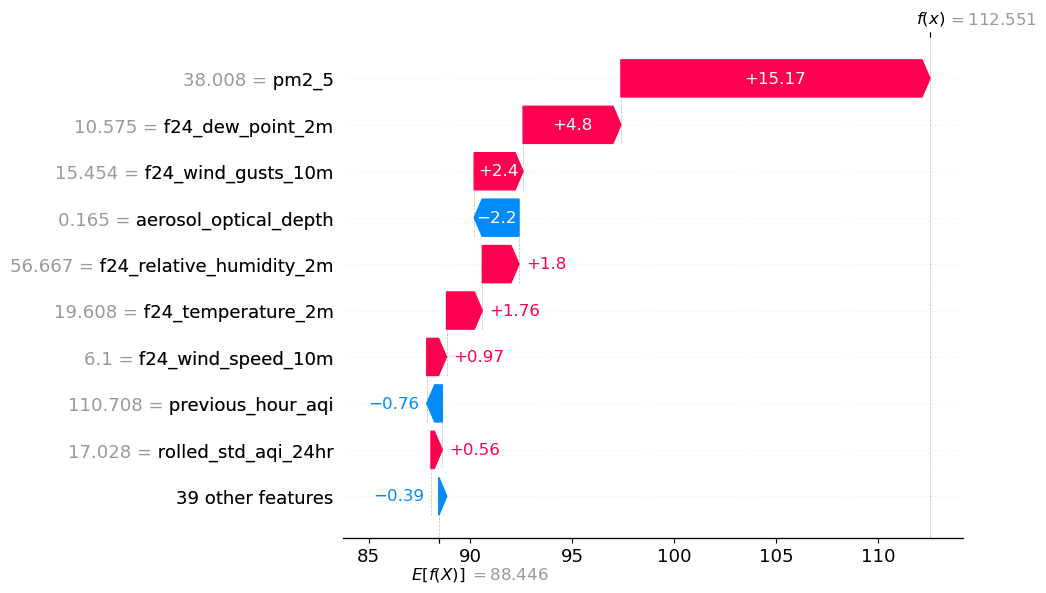

In [37]:
shap.plots.waterfall(shap_values[0])

### Beeswarm Plot

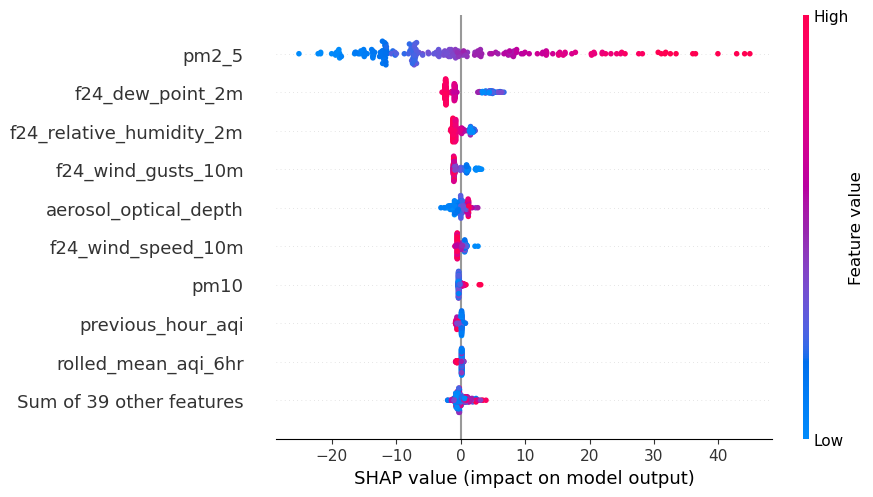

In [38]:
shap.plots.beeswarm(shap_values)

# Prediction Chart

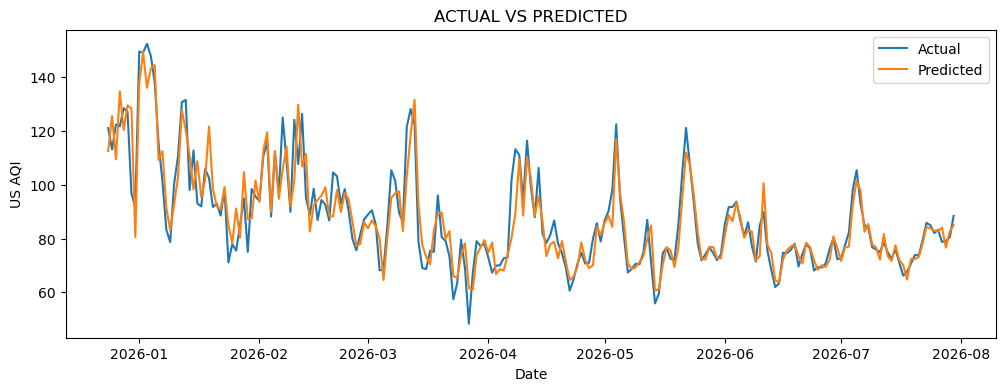

In [39]:
plt.figure(figsize=(12,4))
y_pred_tuned = best_random.predict(X_test1)
plt.plot(Y_test1.index, Y_test1.values, label="Actual")
plt.plot(Y_test1.index, y_pred_tuned, label="Predicted")
plt.legend(loc = "best")
plt.title("ACTUAL VS PREDICTED")
plt.ylabel("US AQI")
plt.xlabel("Date")
plt.show()